In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt


In [ ]:
# set random seeds for reproducibility
torch.manual_seed(42)

In [ ]:
# check for gpu
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "fashion-mnist_train.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sanjeet41/fashionmnist-train",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_1684/3148370602.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 33.6M/33.6M [00:02<00:00, 11.8MB/s]

Extracting zip of fashion-mnist_train.csv...


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0,0,105,92,101,107,100,132,0,0,2,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,150,...,211,220,214,74,0,255,222,128,0,0,0,0,0,0,0,0,0,44,12,0,0,40,134,162,191,214,163,146,165,79,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,0,114,183,112,55,23,72,102,165,160,28,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,24,188,163,93,...,171,249,207,197,202,45,0,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,22,21,25,69,52,45,74,39,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,0,0,0,46,0,21,68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,187,189,...,230,237,229,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68,116,112,136,147,144,121,102,63,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

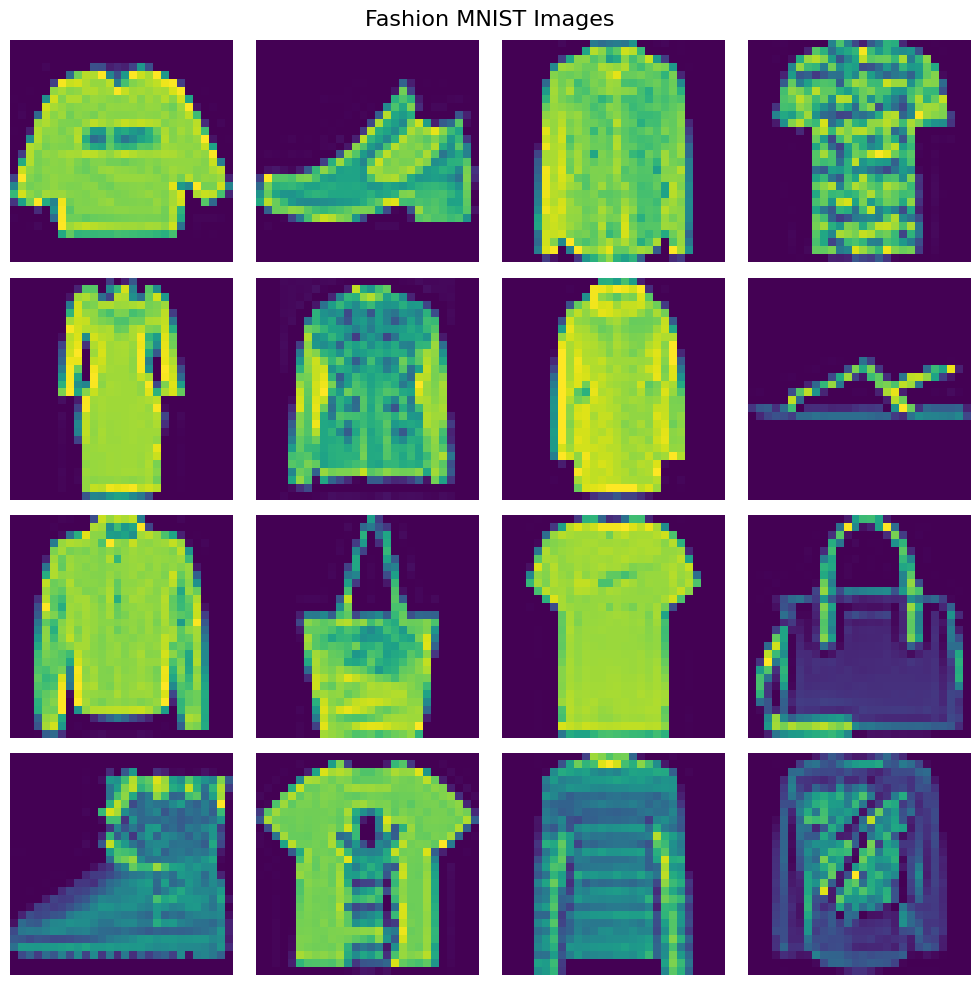

In [ ]:
# create a 4*4 grid of images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("Fashion MNIST Images",fontsize=16)

# plot the first 16 images from the dataset
for i ,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):

    # convert to Pytorch tensors
    self.features=torch.tensor(features,dtype=torch.float32).reshape(-1,1,28,28)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [ ]:
train_dataset=CustomDataset(X_train,y_train)
test_dataset=CustomDataset(X_test,y_test)

In [ ]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

In [ ]:
class MyNN(nn.Module):
  def __init__(self,input_feature):
    super().__init__()

    self.features=nn.Sequential(
        nn.Conv2d(input_feature,32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(32,64,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )

    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(64,10)
    )

  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)

    return x


In [ ]:
learning_rate=0.01
epochs=100

In [ ]:
from torch import optim
model=MyNN(1)

model.to(device)

criterion=nn.CrossEntropyLoss()

optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

In [ ]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)


    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6381137271424134
Epoch: 2 , Loss: 0.38086568752427896
Epoch: 3 , Loss: 0.3267866831595699
Epoch: 4 , Loss: 0.28898062951366105
Epoch: 5 , Loss: 0.2631976843724648
Epoch: 6 , Loss: 0.24068249988307555
Epoch: 7 , Loss: 0.22573041557272275
Epoch: 8 , Loss: 0.2117730065981547
Epoch: 9 , Loss: 0.19453704315361878
Epoch: 10 , Loss: 0.18507646988518536
Epoch: 11 , Loss: 0.17832411370798945
Epoch: 12 , Loss: 0.16628367047881087
Epoch: 13 , Loss: 0.15310208231024444
Epoch: 14 , Loss: 0.1462802497278899
Epoch: 15 , Loss: 0.1399956324606513
Epoch: 16 , Loss: 0.13215651469274114
Epoch: 17 , Loss: 0.12388375702283035
Epoch: 18 , Loss: 0.11860249045553306
Epoch: 19 , Loss: 0.11011341955636939
Epoch: 20 , Loss: 0.10534172601012202
Epoch: 21 , Loss: 0.10123514149229353
Epoch: 22 , Loss: 0.0955301983677006
Epoch: 23 , Loss: 0.09259078276219468
Epoch: 24 , Loss: 0.08611139762432625
Epoch: 25 , Loss: 0.08273712592440037
Epoch: 26 , Loss: 0.08123238303805314
Epoch: 27 , Loss: 0.07403229

In [ ]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# evaluation on text data
total=0
correct=0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs=model(batch_features)

    _,predicted=torch.max(outputs.data,1)

    total+=batch_labels.size(0)

    correct+=(predicted==batch_labels).sum().item()
print(correct/total)

0.924


In [ ]:
# evaluation on training data
total=0
correct=0

with torch.no_grad():
  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs=model(batch_features)
    _,predicted=torch.max(outputs,1)

    total=total+batch_labels.size(0)
    correct=correct+(predicted==batch_labels).sum().item()

print('Accuracy of the network on the training data: %d %%' % (
    100 * correct / total))

Accuracy of the network on the training data: 99 %
